# Block-level WZA mirror Manhattans — SNP vs SV, LFMM, clq0.9 tiling, all 20 axes

Plots the **output** of the WZA (one corrected `Z_pVal` per LD block) on the settled regime:

| | |
|---|---|
| blocks | clq0.9 BigLD islands, **tiling** assignment (0% of records dropped; strict dropped 39.7% SNP / 49.3% SV) |
| cap | **none** (upstream's own default) |
| SD fit | **isotonic** (monotone, flat past support; cannot go ≤0) |
| mean fit | **poly_clamp degree 5** (upstream fits a polynomial here too; clamped at the support edge) |

Source: `results/multiaxis/wza/wza_lfmm_{cls}_gen9_{axis}_final.csv`.
The per-record p-values that feed this are in `raw_manhattan_snp_vs_sv_lfmm_tile.ipynb`.

---

## ⚠ Read the hit counts as a shortlist, not as discoveries

Under a **signal-free null** (bio1 site-permuted, so there is nothing to find), this
pipeline still returns **~8.5 Bonferroni-significant blocks per scan** where the nominal
expectation is **0.05** — about **170× anti-conservative**. Cause: the SNP-number
correction standardises the null mean and SD of the block-Z correctly (−0.001, 1.008) but
then reads p off a **Normal**, while the true null block-Z is heavy-tailed from
within-block LD (excess kurtosis +0.79–0.86). No choice of mean/SD fit changes this — the
rate is near-identical across every regime tested, and collapsing pools to sites does not
help either. See `wza_investigation/perm_null_regime.py` and `null_tail_shape.py`.

**And on real data the counts are at or below that null rate** (LFMM: 7.6 snp / 8.0 non-SNP
per axis, versus 8.5 / 8.6 under permutation). So the blocks listed here are *not currently
distinguishable from correction artifacts*. The one exception is **SV**, the only
well-calibrated class (null 0.75/scan, excess kurtosis +0.32) because SV blocks are tiny
(median 4 records).

Treat the gene table at the end as a **ranked shortlist for follow-up**, ordered by
evidence strength and cross-axis recurrence. A block appearing in many axes is more
interesting than one appearing once, since artifacts are axis-specific.

In [1]:
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
import lib
GEA = lib.GEA
WZA = f"{GEA}/phase1_replication/results/multiaxis/wza"
AXES = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
MODEL, CLS, REGIME = "lfmm", "sv", "final"
CHROM_LEN = {"Chr1":30427671,"Chr2":19698289,"Chr3":23459830,"Chr4":18585056,"Chr5":26975502}
CH = list(CHROM_LEN); OFF = {}; _a = 0
for _c in CH: OFF[_c] = _a; _a += CHROM_LEN[_c]
plt.rcParams.update({"figure.dpi":110})
SNP_DARK, SNP_LIGHT = "#495057", "#ADB5BD"
CLS_DARK  = "#c0392b" if CLS == "sv" else "#1B5E20"
CLS_LIGHT = "#e8a58c" if CLS == "sv" else "#66BB6A"

def block_spans_tiling(r2=0.9):
    """Tiling block spans: block i owns (end_{i-1}, end_i] -- matches reblock_blockdef.py."""
    tag=f"clq{r2}"; rows=[]
    for ci in range(1,6):
        ch=f"Chr{ci}"
        g=pd.read_csv(f"{lib.CLQ_BLOCKS_DIR}/chr{ci}_{tag}_blocks_{tag}.tsv",sep="\t").sort_values("start_pos").reset_index(drop=True)
        ends=g.end_pos.to_numpy(np.int64)
        for i in range(len(g)):
            lo = 1 if i==0 else int(ends[i-1])+1
            hi = int(ends[i]) if i<len(g)-1 else 10**9
            rows.append((f"{ch}_{i}", ch, lo, hi))
    return pd.DataFrame(rows,columns=["block","chrom","start","end"]).set_index("block")

SPANS = block_spans_tiling(); GENES = lib.load_genes()
def genes_on(block):
    if block not in SPANS.index: return []
    s = SPANS.loc[block]
    gc = GENES[(GENES.chrom==s.chrom)&(GENES.end>=s.start)&(GENES.start<=s.end)]
    return list(gc.gene)

def load_wza(cls, axis):
    f = f"{WZA}/wza_{MODEL}_{cls}_gen9_{axis}_{REGIME}.csv"
    if not os.path.exists(f): return None
    d = pd.read_csv(f)
    # wza_script writes the window id in the first column, named `index` (not `gene`)
    d = d.rename(columns={d.columns[0]: "block"}) if d.columns[0] != "block" else d
    d = d[d["Z_pVal"].notna()].copy()
    d["nlp"] = -np.log10(d["Z_pVal"].clip(lower=1e-300))
    d["gpos"] = d["chrom"].map(OFF) + d["pos"]
    d["bonf"] = 0.05/len(d)
    return d
print("loaded:", len(SPANS), "tiling blocks,", len(GENES), "genes ; class =", CLS)

loaded: 58376 tiling blocks, 27206 genes ; class = sv


/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


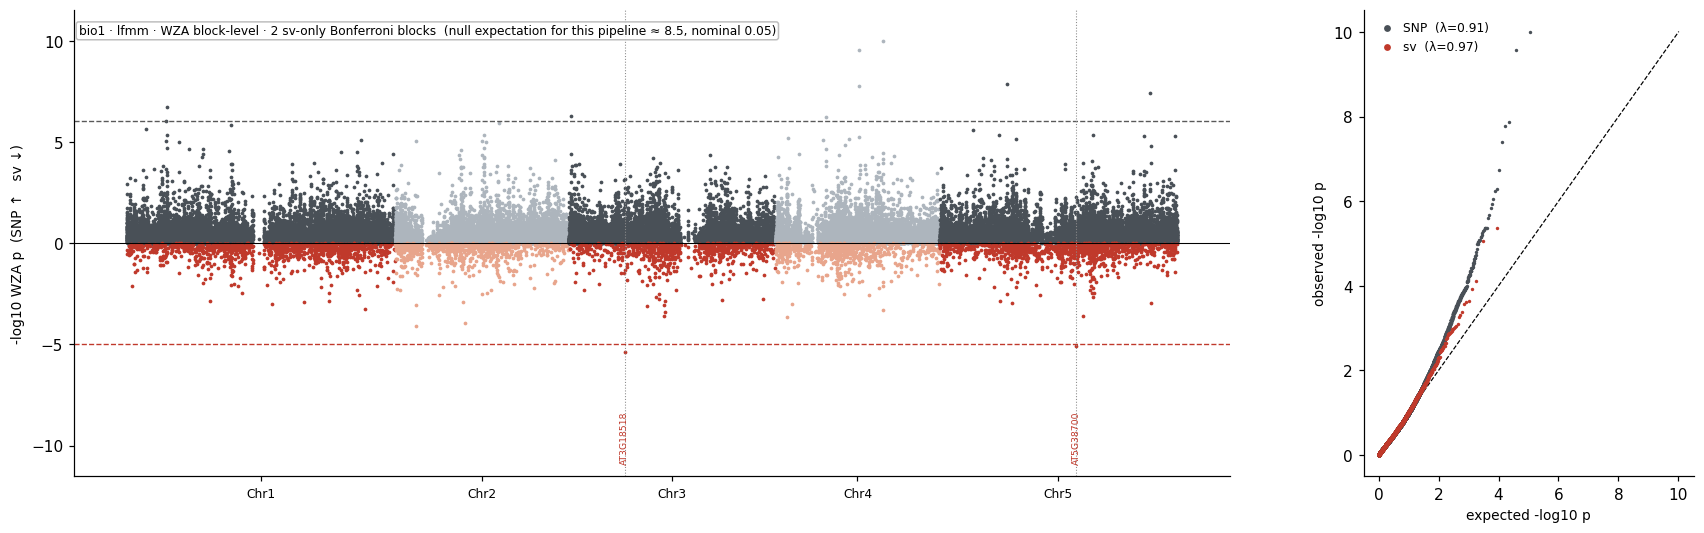

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


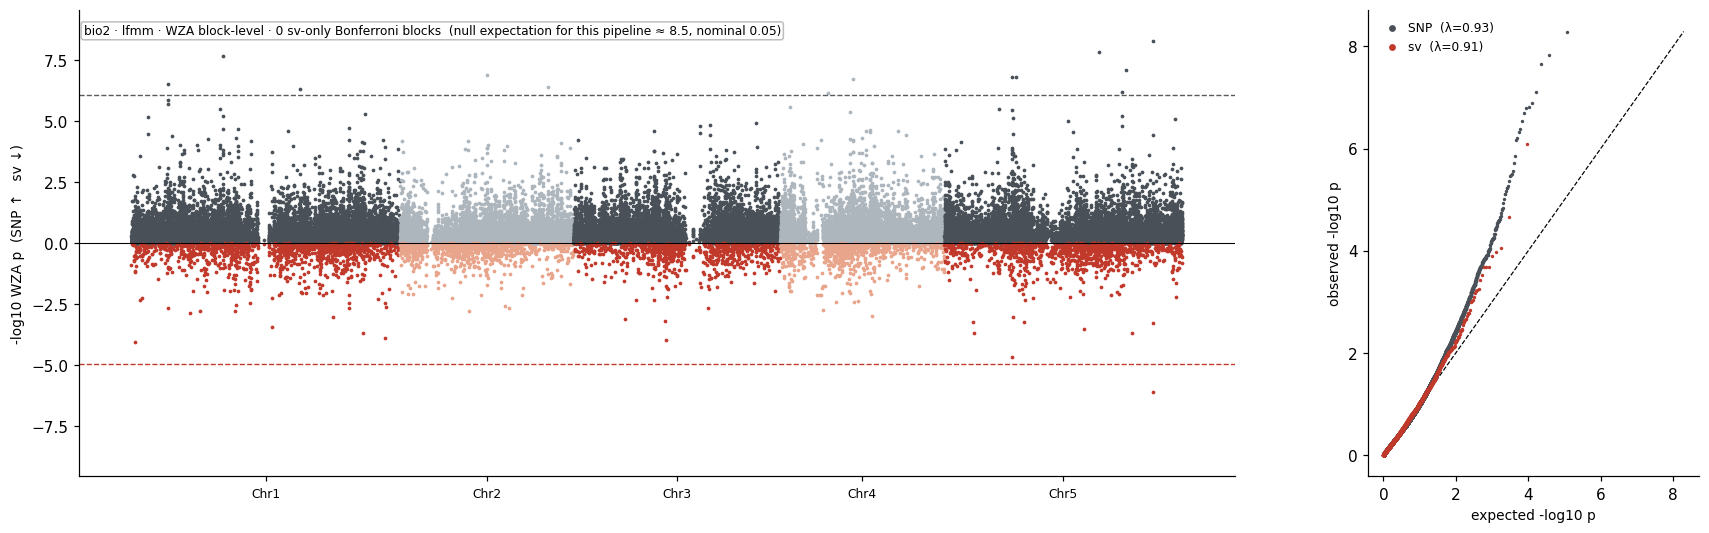

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


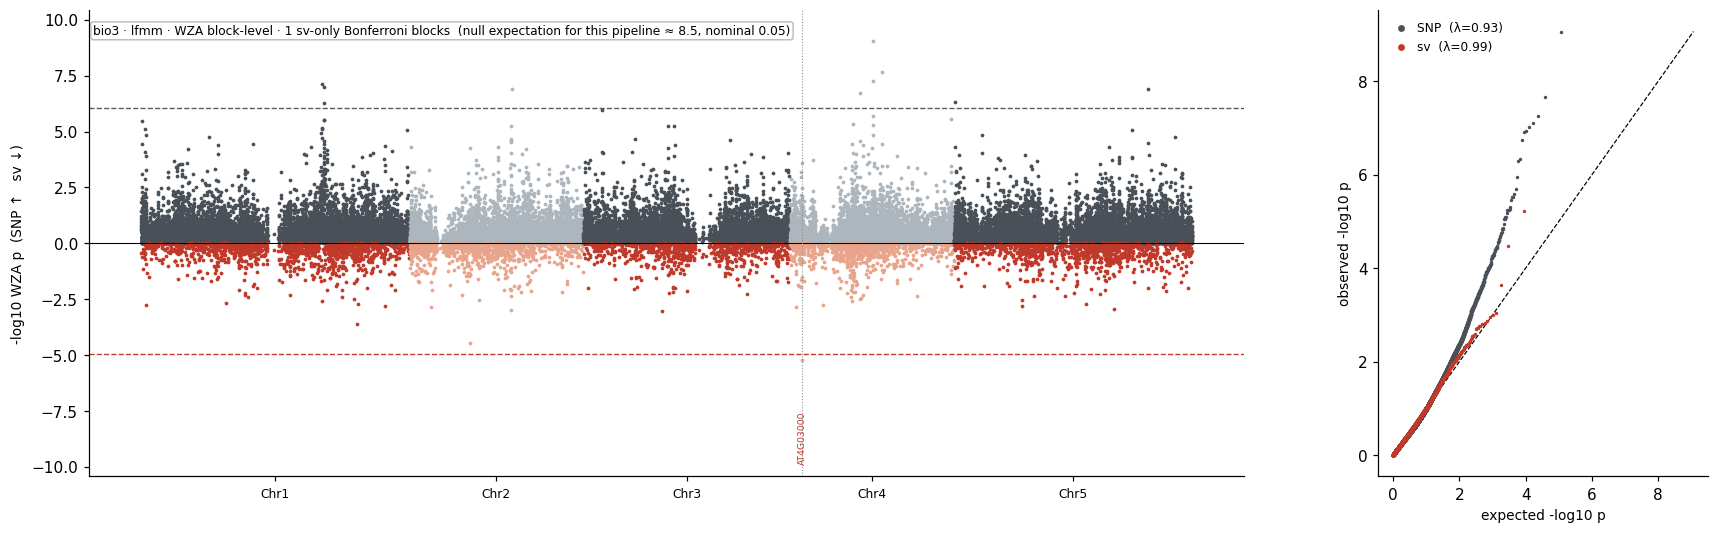

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


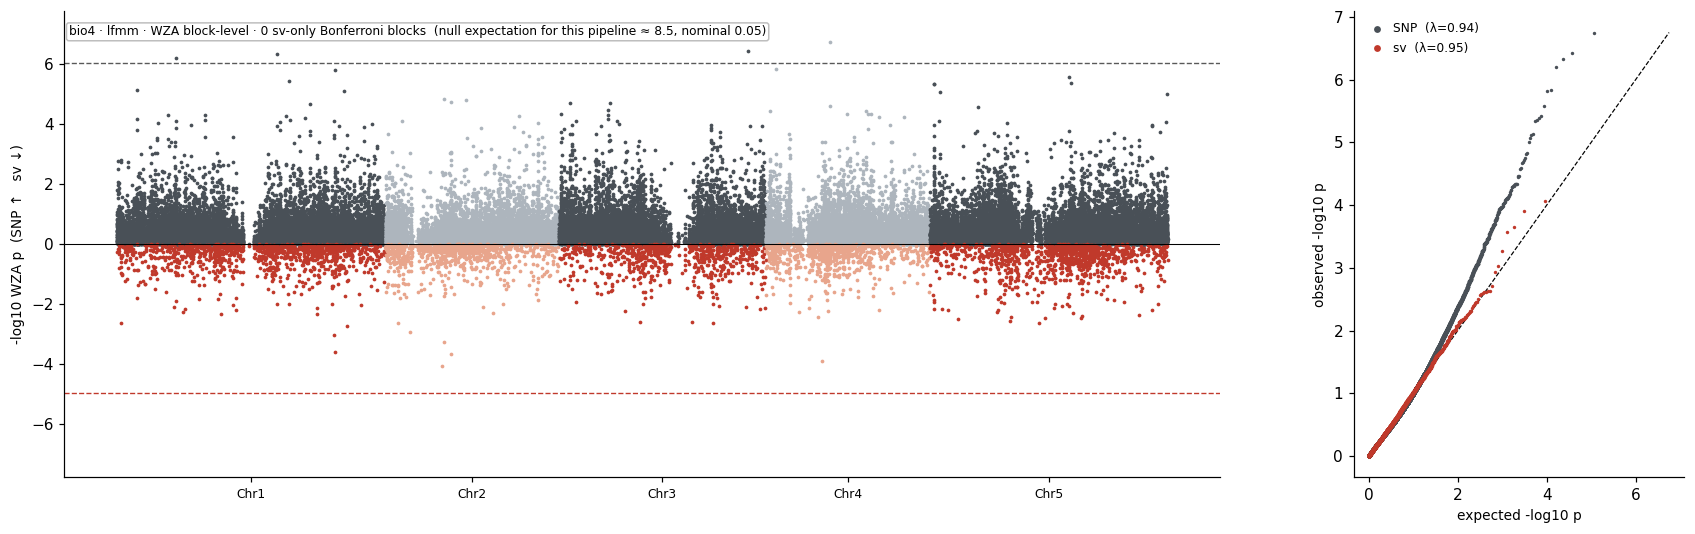

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


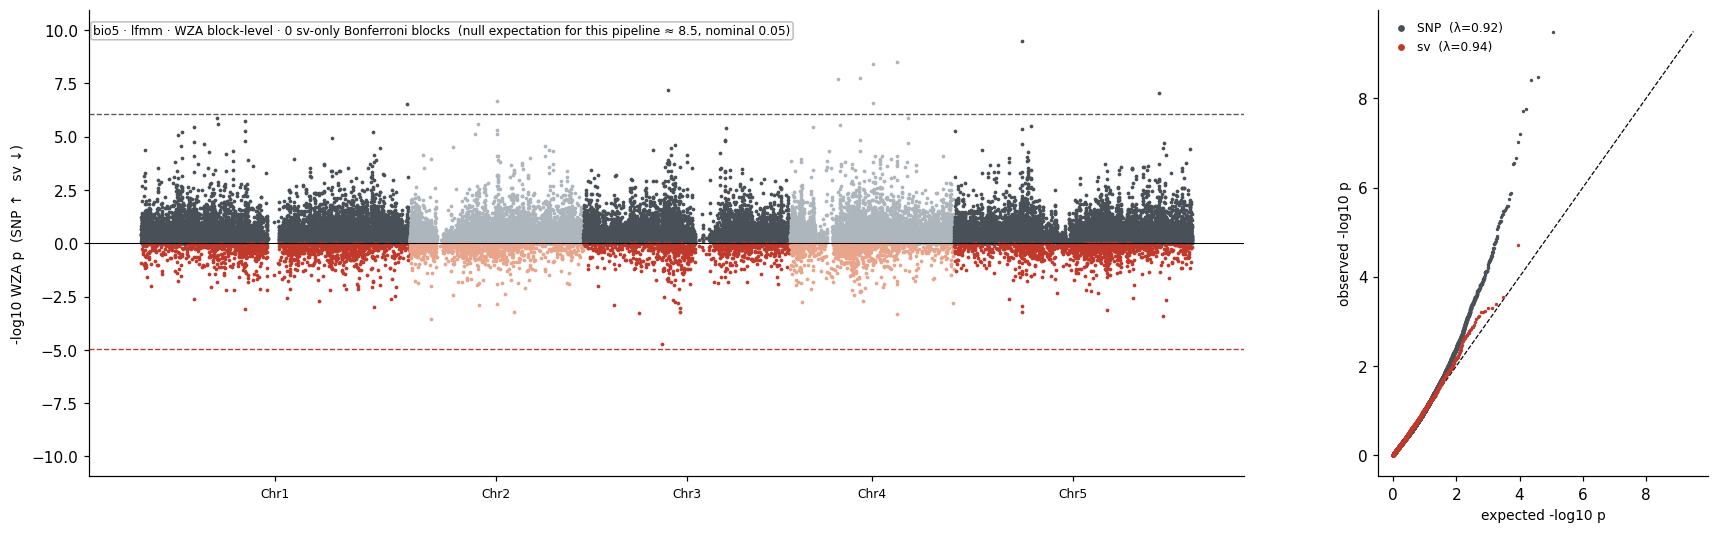

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


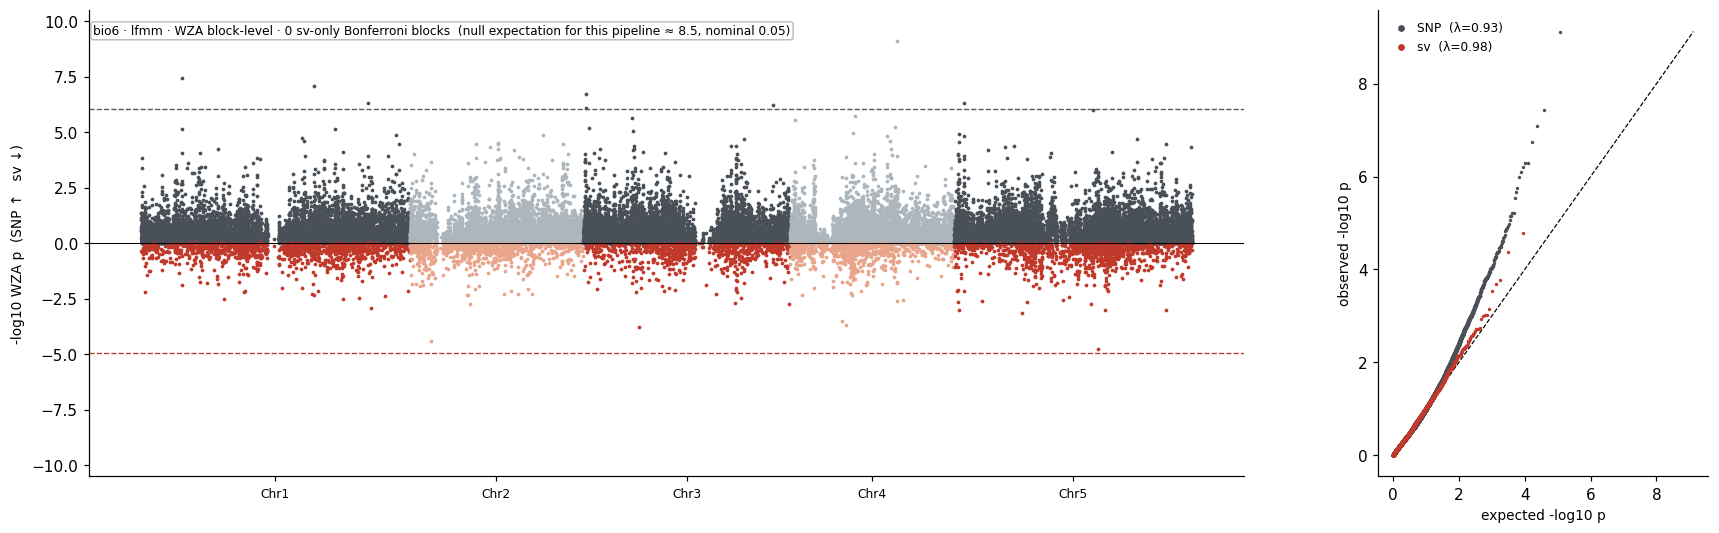

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


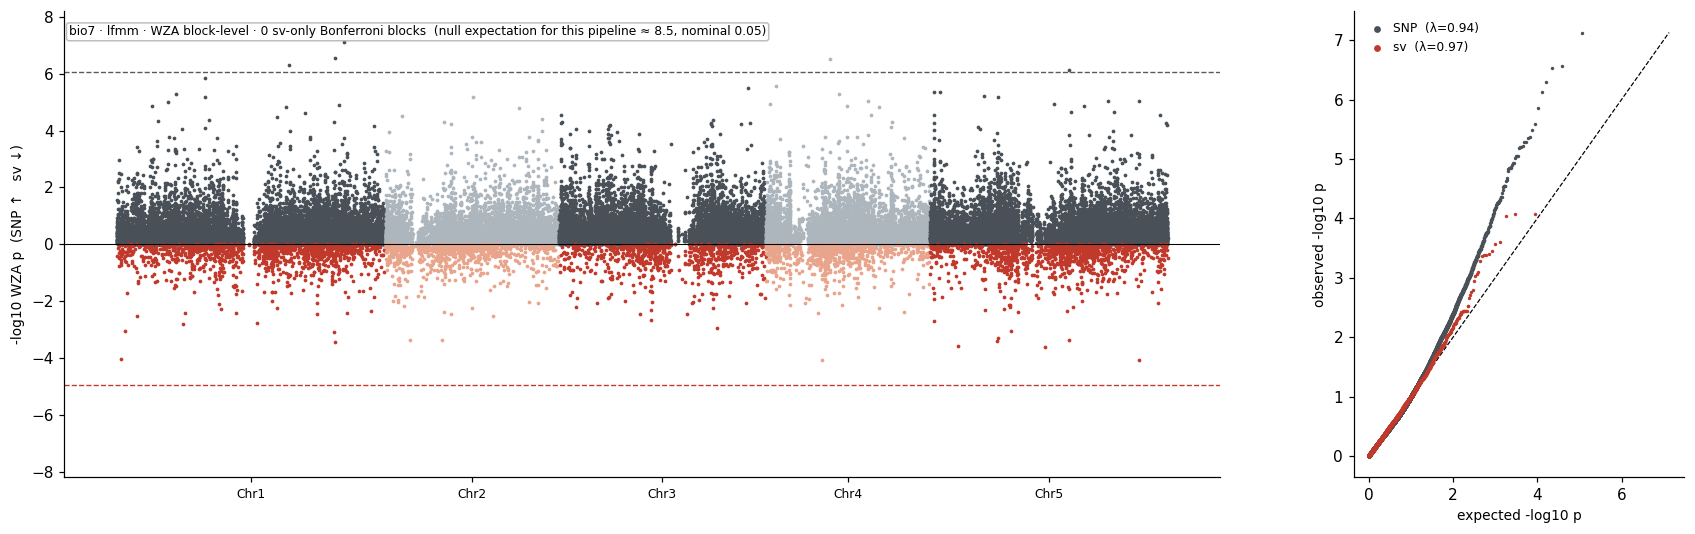

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


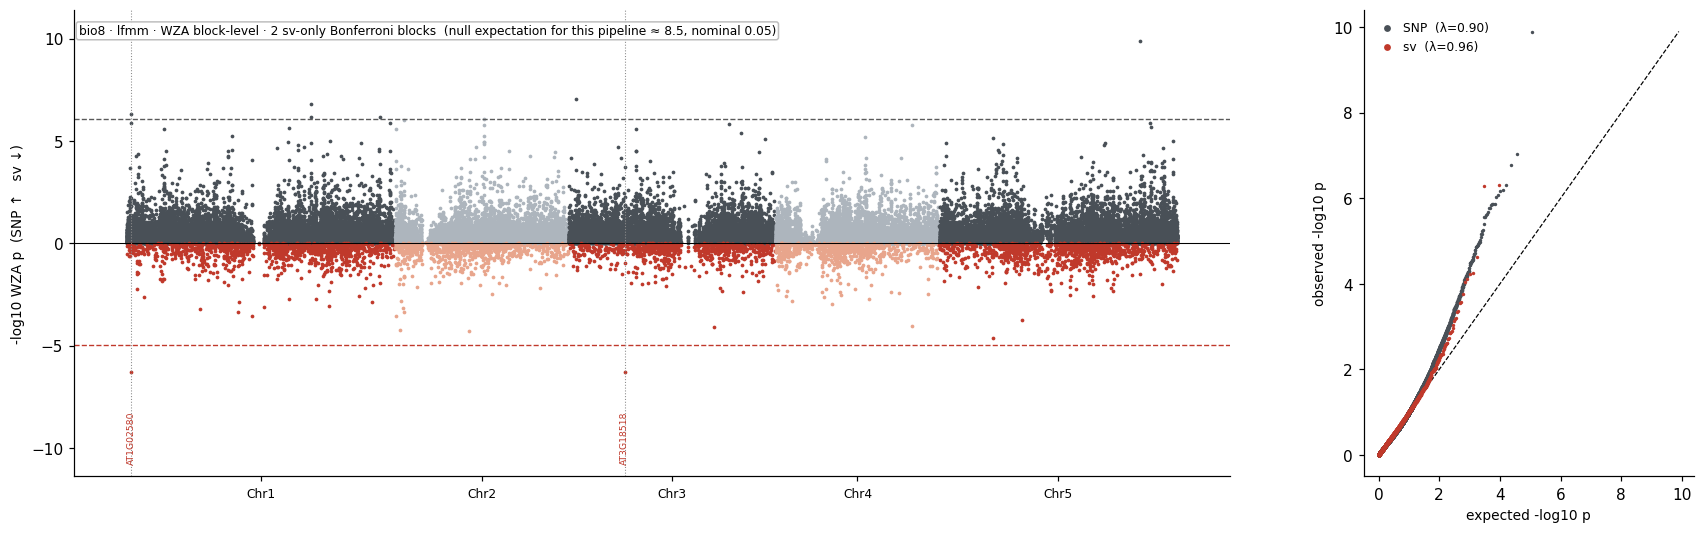

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


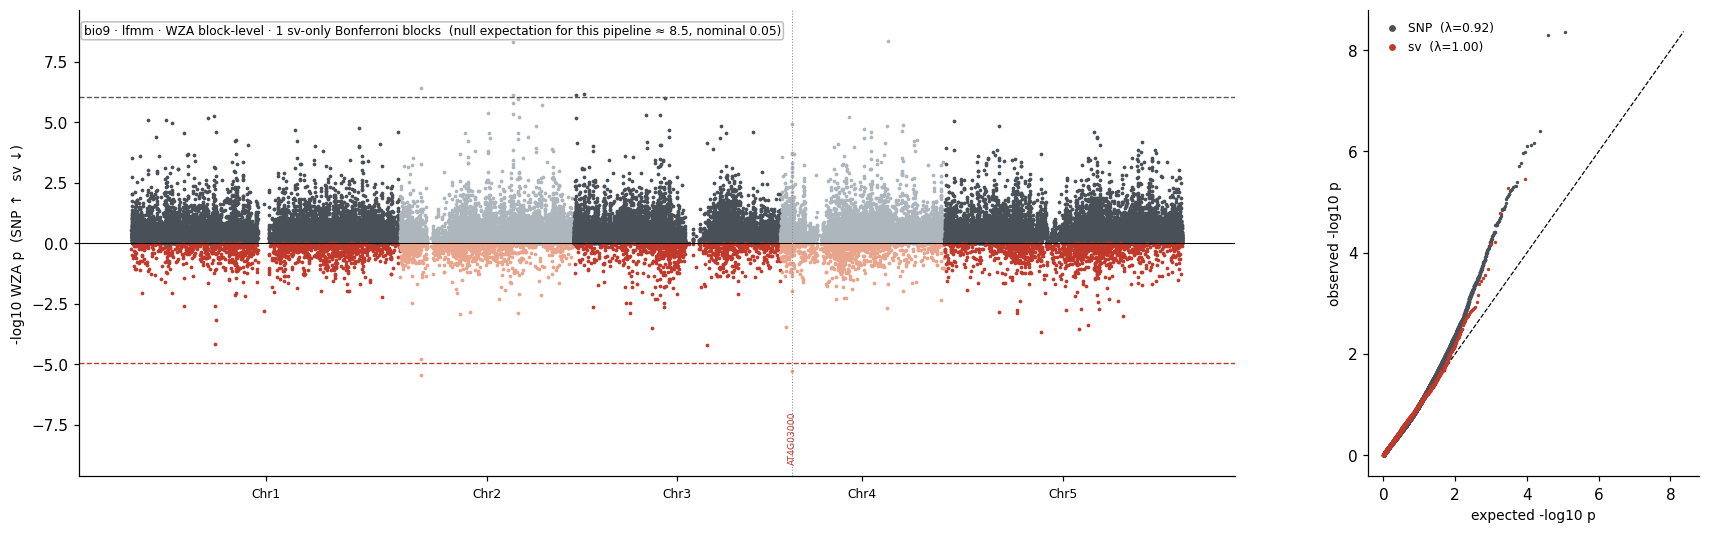

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


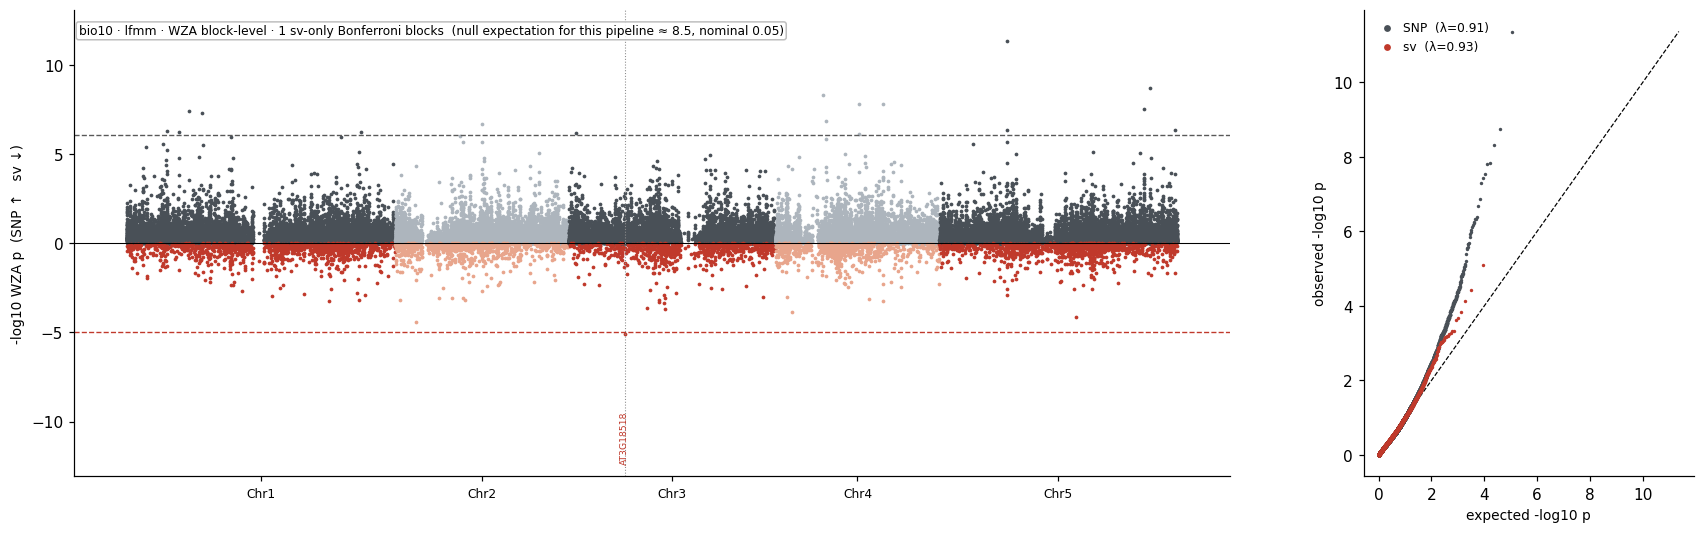

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


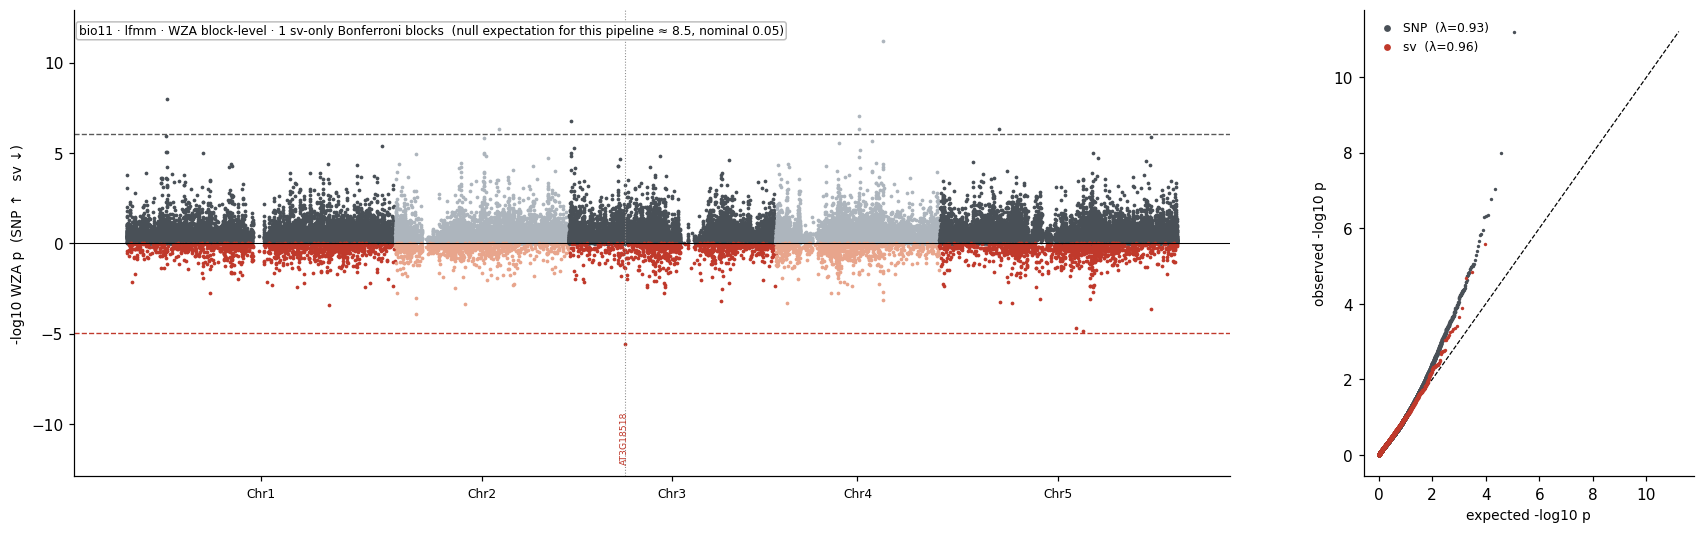

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


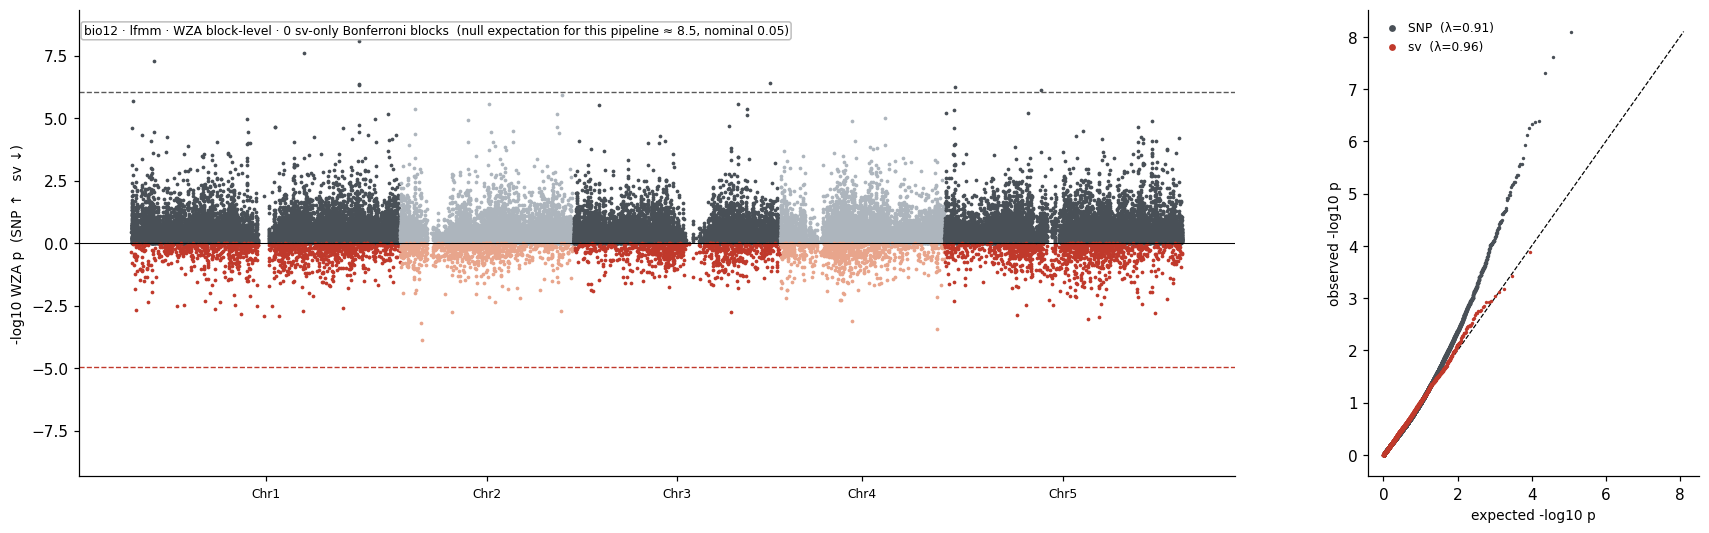

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


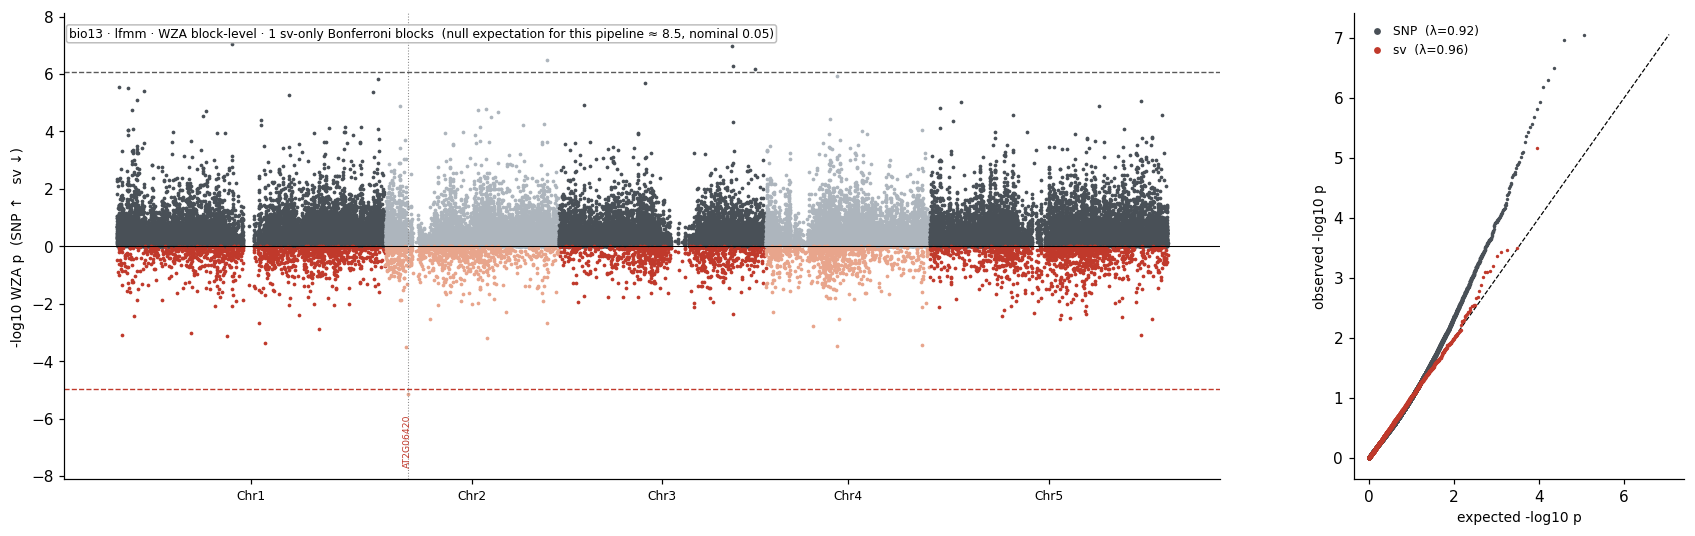

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


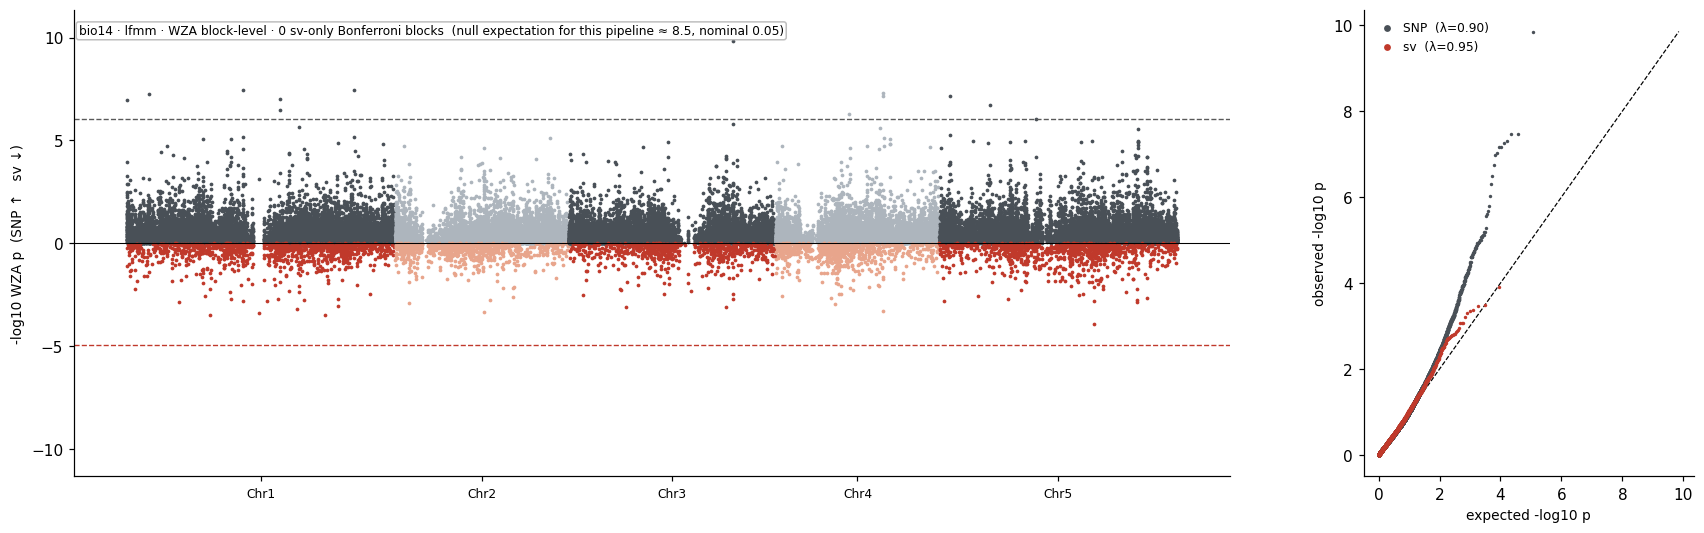

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


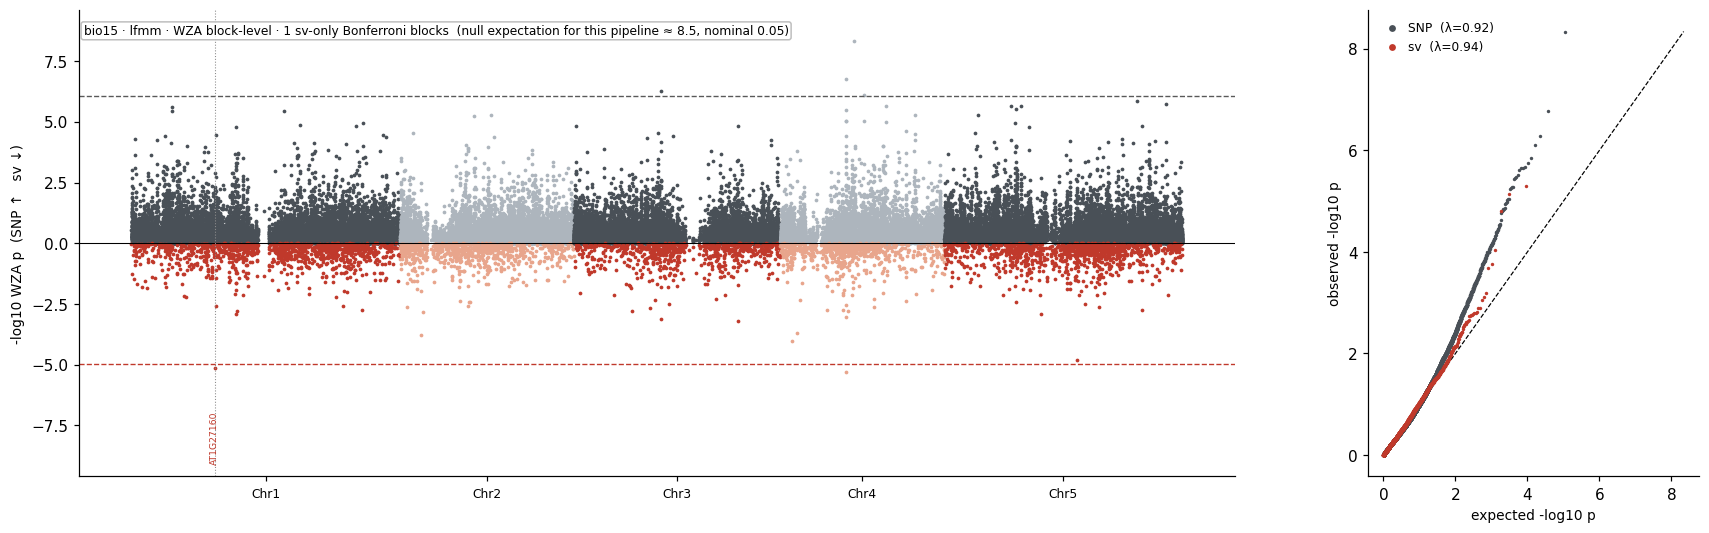

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


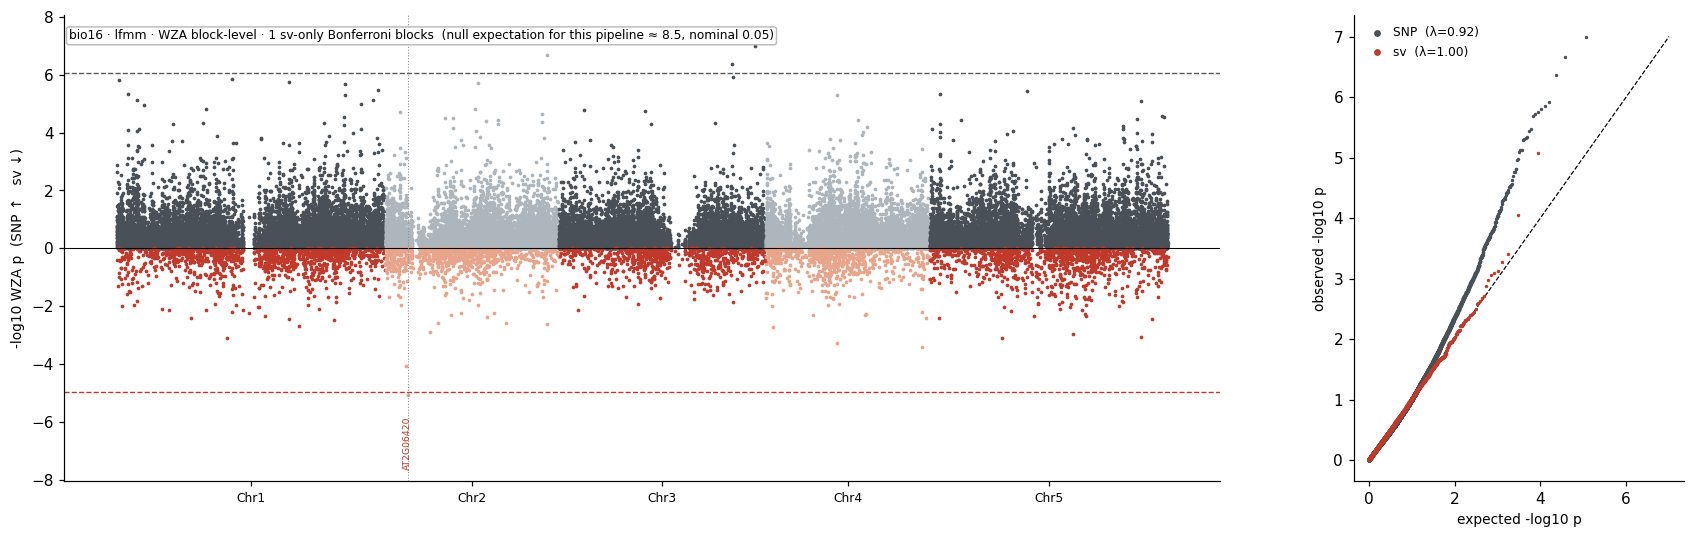

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


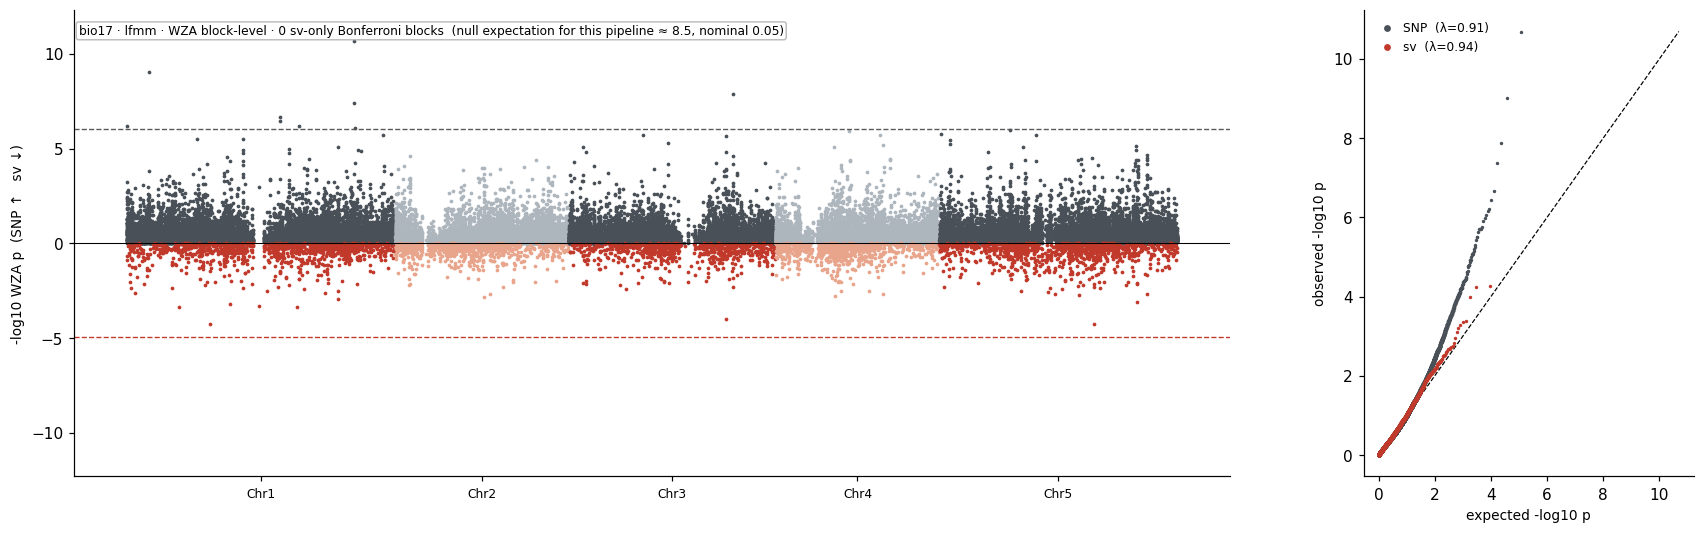

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


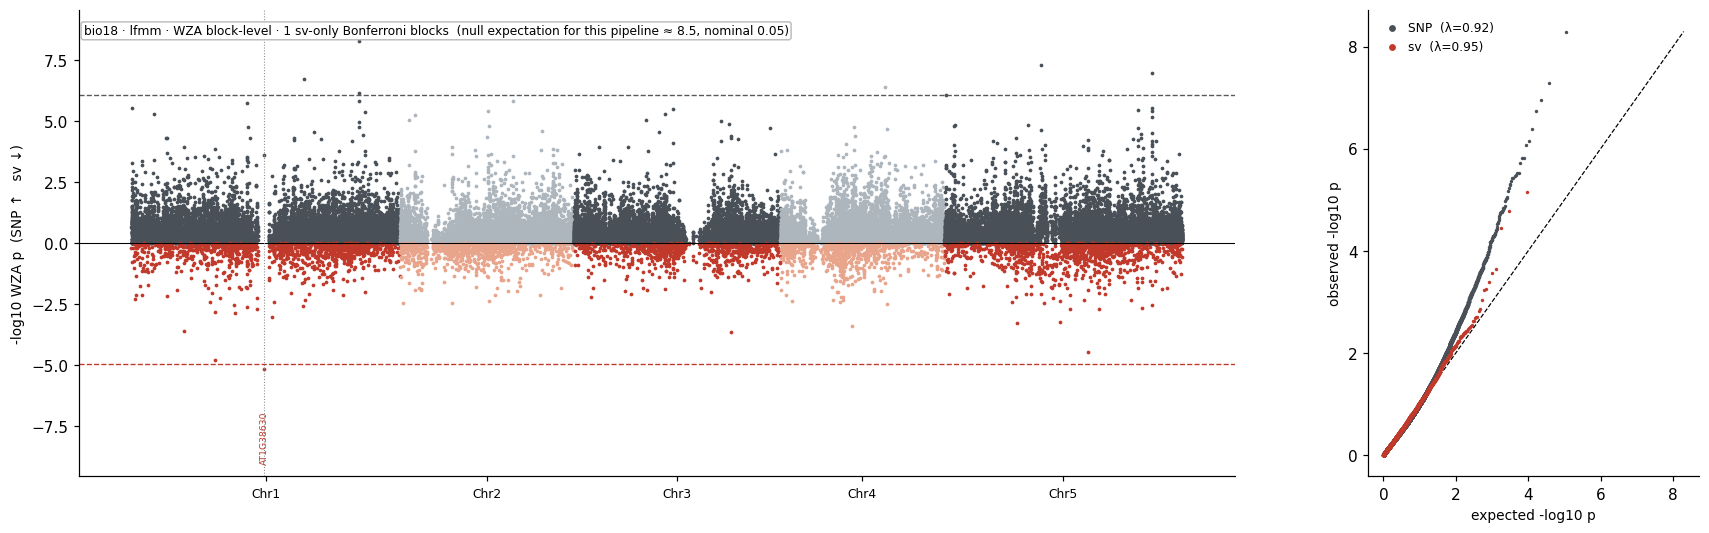

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


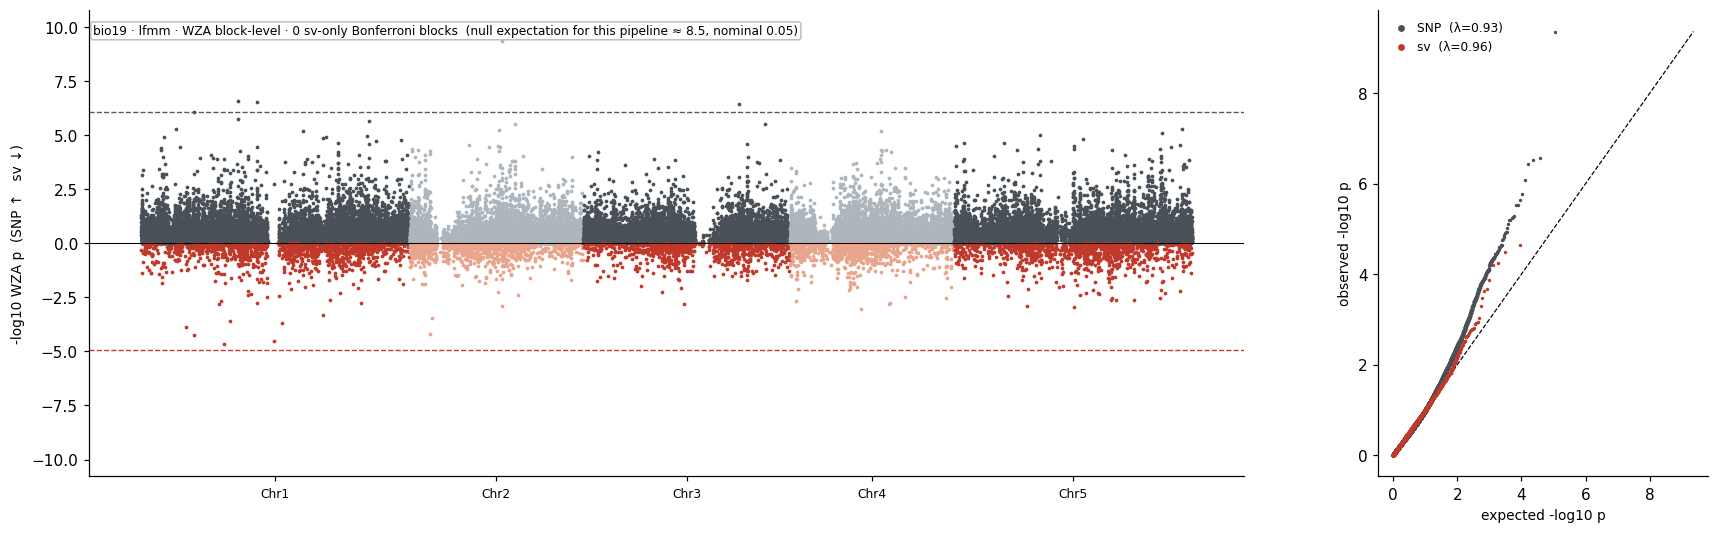

/tmp/ipykernel_2443196/4236942306.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


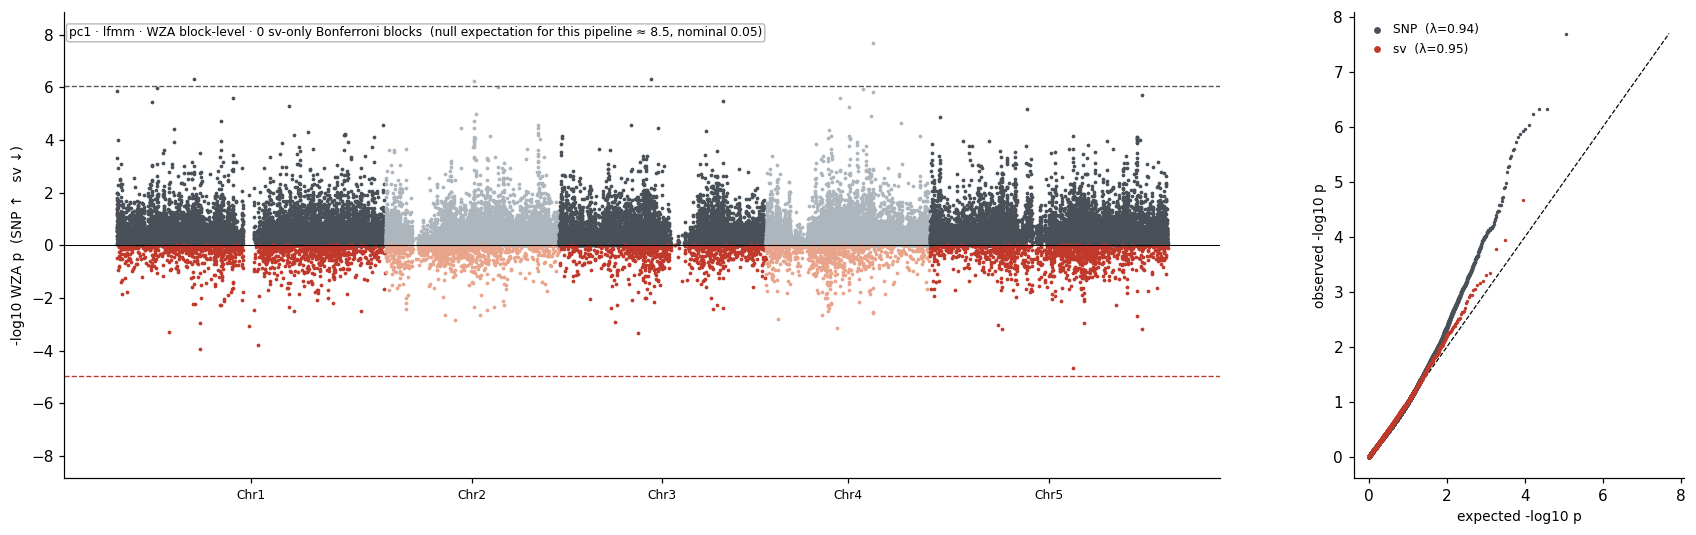


ALL sv Bonferroni block-hits across 20 axes: 15   (of which missed by SNPs: 12)


In [2]:
from scipy import stats

def gif_lambda(p):
    p = np.clip(np.asarray(p, float), 1e-300, 1.0)
    return float(np.median(stats.chi2.isf(p, 1)) / stats.chi2.isf(0.5, 1))

def qq_xy(p, keep_head=15000, n_bulk=3000):
    p = np.sort(np.clip(np.asarray(p, float)[np.isfinite(p)], 1e-300, 1.0))
    n = len(p)
    exp, obs = -np.log10((np.arange(n)+0.5)/n), -np.log10(p)
    if n <= keep_head + n_bulk:
        idx = np.arange(n)
    else:
        idx = np.concatenate([np.arange(keep_head),
                              np.unique(np.geomspace(keep_head, n-1, n_bulk).astype(int))])
    return exp[idx], obs[idx]

def wza_mirror(ax, axis, cls, s, c):
    """SNP up / class down. A 'class-only' peak = block Bonferroni-sig in the class but
    NOT in snp -- i.e. the block is found by this variant class and missed by SNPs."""
    bs, bc = -np.log10(0.05/len(s)), -np.log10(0.05/len(c))
    sig_s = set(s.loc[s.nlp > bs, "block"])
    allsig = c[c.nlp > bc].copy()                     # EVERY Bonferroni-sig class block
    allsig["snp_also_sig"] = allsig["block"].isin(sig_s)
    only = allsig[~allsig.snp_also_sig]               # the subset SNPs miss (labelled on the plot)
    for i, ch in enumerate(CH):
        ss, cc = s[s.chrom == ch], c[c.chrom == ch]
        ax.scatter(ss.gpos, ss.nlp, s=6, c=(SNP_DARK if i%2==0 else SNP_LIGHT), rasterized=True, linewidths=0)
        ax.scatter(cc.gpos, -cc.nlp, s=6, c=(CLS_DARK if i%2==0 else CLS_LIGHT), rasterized=True, linewidths=0)
    ax.axhline(0, c="k", lw=.7)
    ax.axhline(bs, ls="--", c="0.35", lw=.9)
    ax.axhline(-bc, ls="--", c=CLS_DARK, lw=.9)
    ymax = max(s.nlp.max(), c.nlp.max())*1.15
    for _, r in only.iterrows():
        gs = genes_on(r["block"]); lab = gs[0] if gs else r["block"]
        ax.axvline(r.gpos, ls=":", c="0.55", lw=.7)
        ax.annotate(lab, xy=(r.gpos, -ymax*0.95), ha="center", va="bottom", fontsize=6,
                    color=CLS_DARK, rotation=90)
    ax.set_ylim(-ymax, ymax)
    ax.set_xticks([OFF[c]+CHROM_LEN[c]/2 for c in CH]); ax.set_xticklabels(CH, fontsize=8)
    ax.set_ylabel(f"-log10 WZA p  (SNP \u2191   {cls} \u2193)", fontsize=9)
    ax.annotate(f"{axis} \u00b7 lfmm \u00b7 WZA block-level \u00b7 {len(only)} {cls}-only Bonferroni blocks"
                f"  (null expectation for this pipeline \u2248 8.5, nominal 0.05)",
                xy=(0.004, 0.97), xycoords="axes fraction", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=.85))
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    return allsig

def qq_panel(ax, cls, s, c):
    ls_, lc_ = gif_lambda(s.Z_pVal), gif_lambda(c.Z_pVal)
    xs, ys = qq_xy(s.Z_pVal.to_numpy()); xc, yc = qq_xy(c.Z_pVal.to_numpy())
    hi = max(xs.max(), ys.max(), xc.max(), yc.max())
    ax.plot([0,hi],[0,hi], c="k", lw=.8, ls="--", zorder=1)
    ax.scatter(xs, ys, s=5, c=SNP_DARK, rasterized=True, linewidths=0, zorder=2, label=f"SNP  (\u03bb={ls_:.2f})")
    ax.scatter(xc, yc, s=5, c=CLS_DARK, rasterized=True, linewidths=0, zorder=2, label=f"{cls}  (\u03bb={lc_:.2f})")
    ax.set_xlabel("expected -log10 p", fontsize=9); ax.set_ylabel("observed -log10 p", fontsize=9)
    ax.legend(loc="upper left", frameon=False, fontsize=8, markerscale=2, handletextpad=0.3)
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)

HITS = []
for axis in AXES:
    s, c = load_wza("snp", axis), load_wza(CLS, axis)
    if s is None or c is None:
        print(f"missing {axis}"); continue
    fig = plt.figure(figsize=(19, 5.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1], wspace=0.18)
    allsig = wza_mirror(fig.add_subplot(gs[0]), axis, CLS, s, c)
    qq_panel(fig.add_subplot(gs[1]), CLS, s, c)
    fig.tight_layout(); plt.show()
    o = allsig.copy(); o["axis"] = axis
    HITS.append(o[["axis","block","chrom","pos","SNPs","Z","Z_pVal","nlp","bonf","snp_also_sig"]])
HITS = pd.concat(HITS, ignore_index=True) if HITS else pd.DataFrame()
print(f"\nALL {CLS} Bonferroni block-hits across {len(AXES)} axes: {len(HITS)}"
      f"   (of which missed by SNPs: {int((~HITS.snp_also_sig).sum())})")

## All SV Bonferroni block hits, consolidated

**Every block that clears Bonferroni for sv in any axis** — not only the ones SNPs miss.
`n_axes_snp_missed` records in how many of those axes the SNP scan did *not* also reach
Bonferroni, so the SNP-blind subset is still recoverable as a filter rather than being
baked in.

`n_axes` (how many climate axes the same block is hit in) is the single most useful column
here: a correction artifact is axis-specific, whereas real signal should recur across the
strongly correlated climate variables.

In [3]:
if len(HITS):
    rec = (HITS.groupby("block")
                .agg(n_axes=("axis","nunique"), axes=("axis", lambda s: ",".join(sorted(set(s)))),
                     chrom=("chrom","first"), pos=("pos","first"), SNPs=("SNPs","first"),
                     best_p=("Z_pVal","min"), best_nlp=("nlp","max"),
                     n_axes_snp_missed=("snp_also_sig", lambda s: int((~s).sum())))
                .sort_values(["n_axes","best_nlp"], ascending=[False, False]).reset_index())
    rec["genes"] = rec.block.map(lambda b: ";".join(genes_on(b)))
    rec["n_genes"] = rec.genes.map(lambda g: 0 if not g else len(g.split(";")))
    print(f"{len(rec)} distinct {CLS} blocks "
          f"({int((rec.n_axes_snp_missed>0).sum())} missed by SNPs in >=1 axis); "
          f"recurrence across axes:")
    print(rec.n_axes.value_counts().sort_index(ascending=False).to_string())
    print()
    print(rec.head(40).to_string(index=False))
else:
    rec = pd.DataFrame()
    print("no hits")

10 distinct sv blocks (7 missed by SNPs in >=1 axis); recurrence across axes:
n_axes
4    1
2    2
1    7

     block  n_axes                  axes chrom          pos  SNPs       best_p  best_nlp  n_axes_snp_missed                                                                           genes  n_genes
 Chr3_3119       4 bio1,bio10,bio11,bio8  Chr3 6.366989e+06     7 4.958276e-07  6.304669                  4                                                   AT3G18518;AT3G18520;AT3G18524        3
 Chr4_1011       2             bio3,bio9  Chr4 1.345328e+06    11 5.318820e-06  5.274185                  2                     AT4G03000;AT4G03010;AT4G03020;AT4G03030;AT4G03040;AT4G03050        6
 Chr2_1217       2           bio13,bio16  Chr2 2.542070e+06    10 6.959903e-06  5.157397                  2                                                                       AT2G06420        1
  Chr1_330       1                  bio8  Chr1 5.493607e+05     3 5.022284e-07  6.299099                 

## Gene function for those blocks, from the mygene.info API

Via `annotate_genes_tair_uniprot.py` — **TAIR GO (GO Consortium GAF) + UniProt REST**, not
the older mygene-only path. NCBI has no free-text summaries for Arabidopsis loci (0/73 on
this very list), which left the previous category tags name-driven. TAIR+UniProt gives
protein name and curated keywords for 73/73, curated FUNCTION text for 39/73, and lifts
tagged categories 25 → 31/73. See the "Gene annotation" section of
`analysis/grenenet_gea/README.md`.

Genes are attributed to a block by **span overlap** with the tiling block interval, so a
gene can appear for more than one block and a block can carry many genes. Overlap is
positional, not causal — nothing here establishes that a gene drives the association.

In [4]:
import importlib.util
spec = importlib.util.spec_from_file_location(
    "agtu", os.path.abspath(os.path.join(os.getcwd(), "..", "annotate_genes_tair_uniprot.py")))
agtu = importlib.util.module_from_spec(spec); spec.loader.exec_module(agtu)

if len(rec):
    all_genes = sorted({g for gs in rec.genes if gs for g in gs.split(";")})
    print(f"annotating {len(all_genes)} genes via TAIR GAF + UniProt ...", flush=True)
    ANN = agtu.annotate(all_genes).set_index("gene")

    rows = []
    for _, r in rec.iterrows():
        for g in (r.genes.split(";") if r.genes else []):
            i = ANN.loc[g].to_dict() if g in ANN.index else {}
            rows.append(dict(block=r.block, chrom=r.chrom, pos=int(r.pos), n_axes=r.n_axes,
                             n_axes_snp_missed=r.n_axes_snp_missed,
                             axes=r.axes, best_p=r.best_p, SNPs=r.SNPs, gene=g,
                             symbol=i.get("symbol",""),
                             protein_name=i.get("protein_name",""),
                             categories=i.get("categories","") or "",
                             climate_stress_flowering=bool(i.get("categories","")),
                             uniprot=i.get("uniprot",""),
                             uniprot_keywords=(i.get("uniprot_keywords","") or "")[:160],
                             uniprot_function=(i.get("uniprot_function","") or "")[:400],
                             go_bp=";".join((i.get("go_bp","") or "").split(";")[:6])))
    GT = pd.DataFrame(rows).sort_values(["n_axes","best_p"], ascending=[False, True])
    out = f"{GEA}/phase1_replication/results/multiaxis/{CLS}_wza_final_lfmm_bonf_genes.csv"
    GT.to_csv(out, index=False)
    print(f"\n{len(GT)} (block, gene) pairs over {GT.block.nunique()} blocks "
          f"and {GT.gene.nunique()} genes -> {out}")
    print(f"climate/stress/flowering-tagged: {int(GT.climate_stress_flowering.sum())}"
          f" / {len(GT)} pairs\n")
    print(GT[["block","n_axes","n_axes_snp_missed","best_p","gene","symbol",
              "protein_name","categories"]].head(60).to_string(index=False, max_colwidth=44))
else:
    GT = pd.DataFrame(); print("nothing to annotate")

annotating 31 genes via TAIR GAF + UniProt ...


annotating 31 genes

-- TAIR GAF (GO Consortium) --


GAF cache: /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_gea/phase1_replication/results/cache/tair.gaf.gz (7.2 MB)


   GO for 25/31 genes
-- UniProt REST pass 1: reviewed / Swiss-Prot (taxid 3702) --


  uniprot 31/31 -> 14 mapped


   reviewed: 14/31 genes
-- UniProt REST pass 2: unreviewed / TrEMBL for the remaining 17 --


  uniprot 17/17 -> 15 mapped


   UniProt total: 29/31 genes
-- mygene.info (kept for GO term NAMES + entrez) --



31 (block, gene) pairs over 10 blocks and 31 genes -> /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_gea/phase1_replication/results/multiaxis/sv_wza_final_lfmm_bonf_genes.csv
climate/stress/flowering-tagged: 12 / 31 pairs

     block  n_axes  n_axes_snp_missed       best_p      gene    symbol                                 protein_name                          categories
 Chr3_3119       4                  4 4.958276e-07 AT3G18518      DVL7 Small polypeptide DEVIL 7 (Small polypept...                                    
 Chr3_3119       4                  4 4.958276e-07 AT3G18520     HDA15         Histone deacetylase 15 (EC 3.5.1.98)             temperature,water,light
 Chr3_3119       4                  4 4.958276e-07 AT3G18524      MSH2 DNA mismatch repair protein MSH2 (AtMSH2)...                       light,defense
 Chr4_1011       2                  2 5.318820e-06 AT4G03000     RF298 Putative E3 ubiquitin-protein ligase RF29...                             defen

### Functional category summary

Counts of the curated categories across the annotated genes. With the calibration caveat
above, read this as "what is in the shortlist", not as enrichment — there is no background
comparison here, so it cannot support a claim that any category is over-represented.

In [5]:
if len(GT):
    from collections import Counter
    cnt = Counter(c for cs in GT.categories for c in (cs.split(",") if cs else []) if c)
    if cnt:
        print(pd.Series(cnt).sort_values(ascending=False).to_string())
    else:
        print("no category hits")
    print(f"\ntop blocks by cross-axis recurrence:")
    print(GT.groupby("block").agg(n_axes=("n_axes","first"), best_p=("best_p","first"),
                                  genes=("symbol", lambda s: ",".join(x for x in s if x)[:70]))
            .sort_values("n_axes", ascending=False).head(20).to_string())
else:
    print("nothing")

defense        10
temperature     4
water           4
light           2
flowering       2
oxidative       1

top blocks by cross-axis recurrence:
            n_axes        best_p                                                        genes
block                                                                                        
Chr3_3119        4  4.958276e-07                                              DVL7,HDA15,MSH2
Chr2_1217        2  6.959903e-06                                                    AT2G06420
Chr4_1011        2  5.318820e-06                RF298,AT4G03010,AT4G03020,OR23,AT4G03040,AOP3
Chr1_330         1  5.022284e-07                                                          MEA
Chr1_5053        1  7.382676e-06                                          AT1G27160,AT1G27170
Chr1_7218        1  6.998120e-06  AT1G38790,AT1G40083,AT1G40087,AT1G40104,AT1G40129,AT1G40390
Chr2_1202        1  3.536405e-06                                          AT2G06090,AT2G06095
Chr4_309